Target: close_vix ngay+5 > close_vix hom nay
Chien luoc: position sizing lien tuc theo xac suat (khong threshold cung)
So dong: 2447 | So feature: 41

BUOC 1: WALK-FORWARD SO SANH MODEL (5 fold)
Fold 1: LogReg AUC=0.5718 | XGBoost AUC=0.5443
Fold 2: LogReg AUC=0.6308 | XGBoost AUC=0.5396
Fold 3: LogReg AUC=0.5528 | XGBoost AUC=0.5160
Fold 4: LogReg AUC=0.4409 | XGBoost AUC=0.4821
Fold 5: LogReg AUC=0.6474 | XGBoost AUC=0.5890
----------------------------------------------------------------------
LogReg  AUC: mean=0.5687  std=0.0730
XGBoost AUC: mean=0.5342  std=0.0352
>>> Model tot hon: logreg
Fold 1: proba trung binh=0.196 (2020-05-06 -> 2021-07-29)
Fold 2: proba trung binh=0.497 (2021-07-30 -> 2022-10-18)
Fold 3: proba trung binh=0.178 (2022-10-19 -> 2024-01-04)
Fold 4: proba trung binh=0.605 (2024-01-05 -> 2025-03-31)
Fold 5: proba trung binh=0.321 (2025-04-01 -> 2026-06-23)

BUOC 3: BACKTEST POSITION SIZING LIEN TUC THEO XAC SUAT
Giai doan OOS: 2020-05-06 -> 2026-06-22
Ty trong dau

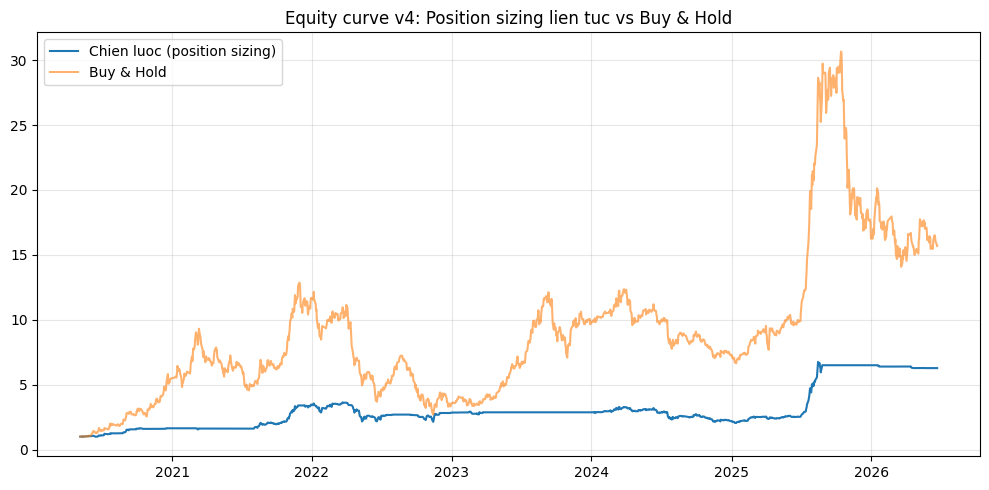

In [1]:
"""
============================================================================
PIPELINE v4 - POSITION SIZING LIEN TUC THEO XAC SUAT (bo han threshold cung)

Van de tim ra o v3: threshold nhi phan tune rieng tung fold qua bat on
(0.821, 0.000, 0.076, 0.003, 0.273) khien thoi gian trong thi truong dao
dong cuc lon giua cac fold (1.3% -> 90.2%) - khong phai do chien luoc sai,
ma do viec ep xac suat lien tuc thanh quyet dinh nhi phan (vao/ra) qua
nhay cam voi nhieu nho quanh nguong.

SUA: dung THANG XAC SUAT CUA MODEL LAM TY TRONG DAU TU TRUC TIEP (khong
threshold roi rac nua):
  exposure_t = clip((proba_t - 0.5) * SCALE + 0.5, 0, 1)
  - proba=0.5 (khong chac) -> exposure=0.5 (trung lap)
  - proba tien ve 1 (tu tin tang) -> exposure tien ve 1 (full vi the)
  - proba tien ve 0 (tu tin giam) -> exposure tien ve 0 (dung ngoai)
  SCALE > 1 lam sac net hoa muc do tin cay (mac dinh SCALE=2.5)

  Them SMOOTH_WINDOW (trung binh truot proba vai ngay) de giam nhieu
  ngay-qua-ngay, tranh dao vi the qua nhieu (giam phi giao dich).

  Phi tinh theo TURNOVER thuc te: cost_t = |exposure_t - exposure_{t-1}| * cost
  (khong phai phi co dinh moi lan doi trang thai nhu truoc).

Cai dat:
    pip install scikit-learn pandas numpy matplotlib joblib xgboost
============================================================================
"""

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("[Canh bao] Chua cai xgboost -> chi chay Logistic Regression. "
          "Cai them: pip install xgboost")

# ============================================================================
# 0. CAU HINH
# ============================================================================
CSV_PATH = "vix_features_1D_updated.csv"
PRICE_COL = "close_vix"
HOLD_DAYS = 5
N_FOLDS = 5
ROUND_TRIP_COST = 0.003
SEED = 42

EXPOSURE_SCALE = 2.5     # do "sac net" cua ty trong theo do tu tin (>1 = quyet doan hon)
SMOOTH_WINDOW = 3        # trung binh truot proba (ngay) de giam nhieu, giam turnover

ALL_TARGET_COLS = [
    "target_close_T1", "target_return_T1", "target_trend_T1",
    "target_close_T3", "log_return_T3", "target_trend_T3",
    "max_close_next_5_days", "log_return_max", "target_trend_T5",
    "max_close_next_3_days_after_T2", "log_return_max_real", "target_trend_T5_Real",
]
NON_FEATURE_COLS = ["time", "id", "auto_id", "Unnamed: 0", "index"]

MODEL_OUT_PATH = "vix_trend_model_v4.joblib"
EQUITY_CURVE_PATH = "backtest_equity_curve_v4.png"

np.random.seed(SEED)


# ============================================================================
# 1. LOAD DATA + TARGET KHOP BACKTEST
# ============================================================================
def load_data(csv_path, hold_days=HOLD_DAYS):
    df = pd.read_csv(csv_path)
    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values("time").reset_index(drop=True)
    assert PRICE_COL in df.columns

    close = df[PRICE_COL].values
    n = len(df)
    fwd_ret = np.full(n, np.nan)
    for i in range(n - hold_days):
        fwd_ret[i] = close[i + hold_days] / close[i] - 1
    df["target_aligned"] = (fwd_ret > 0).astype(float)

    df = df.iloc[:n - hold_days].reset_index(drop=True)
    y = df["target_aligned"].values

    drop_cols = [c for c in ALL_TARGET_COLS if c in df.columns] + \
                [c for c in NON_FEATURE_COLS if c in df.columns] + ["target_aligned"]
    X = df.drop(columns=drop_cols)

    for col in X.columns:
        if col.lower().startswith("volume") or col == "OBV":
            X[col] = np.sign(X[col]) * np.log1p(np.abs(X[col]))
    return df, X, y


def get_fold_boundaries(n, n_folds):
    fold_test_size = n // (n_folds + 3)
    first_train_end = n - n_folds * fold_test_size
    return [
        (first_train_end + f * fold_test_size, first_train_end + f * fold_test_size,
         first_train_end + f * fold_test_size + fold_test_size)
        for f in range(n_folds)
    ]


def make_xgb(scale_pos_weight):
    return XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight, eval_metric="auc", random_state=SEED,
    )


def make_logreg():
    return LogisticRegression(class_weight="balanced", max_iter=2000)


def fit_model(model_type, X_train_s, y_train):
    if model_type == "xgboost":
        spw = (y_train == 0).sum() / max((y_train == 1).sum(), 1)
        model = make_xgb(spw)
    else:
        model = make_logreg()
    model.fit(X_train_s, y_train)
    return model


# ============================================================================
# 2. WALK-FORWARD SO SANH MODEL
# ============================================================================
def walkforward_compare(X, y, n_folds=N_FOLDS):
    print("\n" + "=" * 70)
    print(f"BUOC 1: WALK-FORWARD SO SANH MODEL ({n_folds} fold)")
    print("=" * 70)
    folds = get_fold_boundaries(len(X), n_folds)
    logreg_aucs, xgb_aucs = [], []
    for fold_i, (train_end, test_start, test_end) in enumerate(folds):
        X_train_raw, y_train = X.iloc[:train_end], y[:train_end]
        X_test_raw, y_test = X.iloc[test_start:test_end], y[test_start:test_end]
        sc = StandardScaler()
        X_train_s, X_test_s = sc.fit_transform(X_train_raw), sc.transform(X_test_raw)

        clf = fit_model("logreg", X_train_s, y_train)
        auc_lr = roc_auc_score(y_test, clf.predict_proba(X_test_s)[:, 1])
        logreg_aucs.append(auc_lr)
        line = f"Fold {fold_i+1}: LogReg AUC={auc_lr:.4f}"
        if HAS_XGB:
            xgb = fit_model("xgboost", X_train_s, y_train)
            auc_xgb = roc_auc_score(y_test, xgb.predict_proba(X_test_s)[:, 1])
            xgb_aucs.append(auc_xgb)
            line += f" | XGBoost AUC={auc_xgb:.4f}"
        print(line)

    print("-" * 70)
    print(f"LogReg  AUC: mean={np.mean(logreg_aucs):.4f}  std={np.std(logreg_aucs):.4f}")
    if HAS_XGB:
        print(f"XGBoost AUC: mean={np.mean(xgb_aucs):.4f}  std={np.std(xgb_aucs):.4f}")
    best = "xgboost" if (HAS_XGB and np.mean(xgb_aucs) > np.mean(logreg_aucs)) else "logreg"
    print(f">>> Model tot hon: {best}")
    return best


# ============================================================================
# 3. SINH XAC SUAT OOS (khong can threshold nua)
# ============================================================================
def generate_oos_predictions(df, X, y, model_type, n_folds=N_FOLDS):
    folds = get_fold_boundaries(len(X), n_folds)
    oos_rows = []
    for fold_i, (train_end, test_start, test_end) in enumerate(folds):
        X_train_raw, y_train = X.iloc[:train_end], y[:train_end]
        X_test_raw = X.iloc[test_start:test_end]

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train_raw)
        X_test_s = scaler.transform(X_test_raw)

        model = fit_model(model_type, X_train_s, y_train)
        proba = model.predict_proba(X_test_s)[:, 1]

        fold_df = df.iloc[test_start:test_end][["time", PRICE_COL]].copy()
        fold_df["proba"] = proba
        fold_df["fold"] = fold_i + 1
        oos_rows.append(fold_df)
        print(f"Fold {fold_i+1}: proba trung binh={proba.mean():.3f} "
              f"({fold_df['time'].min().date()} -> {fold_df['time'].max().date()})")

    return pd.concat(oos_rows).sort_values("time").reset_index(drop=True)


# ============================================================================
# 4. BACKTEST POSITION SIZING LIEN TUC (thay the threshold nhi phan)
# ============================================================================
def run_sizing_backtest(oos: pd.DataFrame, cost=ROUND_TRIP_COST,
                         scale=EXPOSURE_SCALE, smooth=SMOOTH_WINDOW):
    oos = oos.reset_index(drop=True).copy()

    # lam min proba de giam nhieu ngay-qua-ngay truoc khi tinh exposure
    oos["proba_smooth"] = oos["proba"].rolling(smooth, min_periods=1).mean()

    # ty trong dau tu = ham tuyen tinh cua do tu tin, cat o [0, 1]
    oos["exposure"] = ((oos["proba_smooth"] - 0.5) * scale + 0.5).clip(0, 1)

    oos["asset_ret"] = oos[PRICE_COL].shift(-1) / oos[PRICE_COL] - 1
    oos = oos.iloc[:-1].reset_index(drop=True)

    # phi theo turnover thuc te (khong phai phi co dinh moi lan doi trang thai)
    oos["turnover"] = oos["exposure"].diff().fillna(oos["exposure"].iloc[0]).abs()
    oos["strategy_ret"] = oos["exposure"] * oos["asset_ret"] - oos["turnover"] * cost

    oos["equity"] = (1 + oos["strategy_ret"]).cumprod()
    oos["buyhold_equity"] = (1 + oos["asset_ret"]).cumprod()
    return oos


def summarize_sizing_backtest(oos: pd.DataFrame):
    print("\n" + "=" * 70)
    print("BUOC 3: BACKTEST POSITION SIZING LIEN TUC THEO XAC SUAT")
    print("=" * 70)

    total_ret = oos["equity"].iloc[-1] - 1
    bh_ret = oos["buyhold_equity"].iloc[-1] - 1
    years = max((oos["time"].max() - oos["time"].min()).days / 365.25, 1e-6)
    cagr = (1 + total_ret) ** (1 / years) - 1
    daily_ret = oos["strategy_ret"]
    sharpe = (daily_ret.mean() / daily_ret.std(ddof=1) * np.sqrt(252)) if daily_ret.std(ddof=1) > 0 else np.nan
    max_dd = (oos["equity"] / oos["equity"].cummax() - 1).min()
    avg_exposure = oos["exposure"].mean()
    total_turnover = oos["turnover"].sum()

    print(f"Giai doan OOS: {oos['time'].min().date()} -> {oos['time'].max().date()}")
    print(f"Ty trong dau tu trung binh: {avg_exposure:.1%}")
    print(f"Tong turnover (do sensitive cua viec doi ty trong): {total_turnover:.2f}")
    print(f"Tong loi nhuan chien luoc: {total_ret:.2%} | CAGR: {cagr:.2%}")
    print(f"Sharpe (hang ngay): {sharpe:.2f} | Max drawdown: {max_dd:.2%}")
    print(f"Buy & Hold cung giai doan: {bh_ret:.2%}")
    print("=> Chien luoc VUOT buy & hold." if total_ret > bh_ret
          else "=> Chien luoc CHUA vuot buy & hold trong giai doan nay.")

    print("\nTy trong dau tu trung binh theo tung fold:")
    print(oos.groupby("fold")["exposure"].mean())

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(oos["time"], oos["equity"], label="Chien luoc (position sizing)")
    ax.plot(oos["time"], oos["buyhold_equity"], alpha=0.6, label="Buy & Hold")
    ax.set_title("Equity curve v4: Position sizing lien tuc vs Buy & Hold")
    ax.legend(); ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(EQUITY_CURVE_PATH, dpi=120)
    print(f"\nDa luu bieu do: {EQUITY_CURVE_PATH}")

    return {"total_return": total_ret, "cagr": cagr, "sharpe": sharpe,
            "max_drawdown": max_dd, "avg_exposure": avg_exposure, "buy_hold_return": bh_ret}


# ============================================================================
# 5. FIT MODEL PRODUCTION TREN TOAN BO LICH SU
# ============================================================================
def train_production_model(X, y, model_type):
    print("\n" + "=" * 70)
    print("BUOC 4: FIT MODEL PRODUCTION TREN TOAN BO DU LIEU LICH SU")
    print("=" * 70)
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    model = fit_model(model_type, X_s, y)

    joblib.dump({
        "model": model, "scaler": scaler,
        "feature_names": list(X.columns), "target": "close_fwd5_up",
        "model_type": model_type, "hold_days": HOLD_DAYS,
        "exposure_scale": EXPOSURE_SCALE, "smooth_window": SMOOTH_WINDOW,
        "strategy": "continuous_position_sizing",
    }, MODEL_OUT_PATH)
    print(f"Da luu model production: {MODEL_OUT_PATH}")


def predict_next(feature_row: dict, recent_probas: list = None, model_path=MODEL_OUT_PATH):
    """
    feature_row: dict feature cua NGAY HOM NAY.
    recent_probas: list xac suat cua (smooth_window - 1) ngay GAN NHAT truoc do
                   (de lam min dung cach). Neu None, dung luon proba hom nay
                   (bo qua buoc lam min).
    Tra ve ty trong dau tu de nghi (0-1). Khong phai khuyen nghi dau tu -- chi
    la cong cu ho tro tham khao, nguoi dung tu chiu trach nhiem quyet dinh.
    """
    bundle = joblib.load(model_path)
    X_new = pd.DataFrame([feature_row])[bundle["feature_names"]]
    X_new_s = bundle["scaler"].transform(X_new)
    proba_today = bundle["model"].predict_proba(X_new_s)[:, 1][0]

    if recent_probas:
        window = list(recent_probas) + [proba_today]
        proba_smooth = np.mean(window[-bundle["smooth_window"]:])
    else:
        proba_smooth = proba_today

    exposure = float(np.clip((proba_smooth - 0.5) * bundle["exposure_scale"] + 0.5, 0, 1))
    return {
        "probability_uptrend": float(proba_today),
        "probability_smoothed": float(proba_smooth),
        "suggested_exposure": exposure,
    }


# ============================================================================
# MAIN
# ============================================================================
def main():
    df, X, y = load_data(CSV_PATH)
    print(f"Target: close_vix ngay+{HOLD_DAYS} > close_vix hom nay")
    print("Chien luoc: position sizing lien tuc theo xac suat (khong threshold cung)")
    print(f"So dong: {len(X)} | So feature: {X.shape[1]}")

    best_model_type = walkforward_compare(X, y)
    oos = generate_oos_predictions(df, X, y, best_model_type)
    oos = run_sizing_backtest(oos)
    summarize_sizing_backtest(oos)

    train_production_model(X, y, best_model_type)
    print("\nHOAN TAT.")


if __name__ == "__main__":
    main()